In [1]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils.data_loader import DataLoader
from src.preprocessing.data_cleaner import DataCleaner
from src.eda.analyzer import EDAAnalyzer
from src.feature_engineering.preprocessor import FeatureEngineer

INFO:src.preprocessing.data_cleaner:DataCleaner initialized.
c:\Users\Mrunmayee Potdar\Desktop\AutoML_studio\src\preprocessing\data_cleaner.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col].fillna(fill_val, inplace = True)
c:\Users\Mrunmayee Potdar\Desktop\AutoML_studio\src\preprocessing\data_cleaner.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work b

CLEANING
    Age   Salary City Purchased
0  25.0  50000.0   NY        No
1  30.0  60000.0   LA       Yes
2  37.5  55000.0   NY       Yes
3  45.0  57500.0   SF        No
4  67.5  70000.0   LA       Yes

EDA
        count     mean          std      min      25%      50%      75%  \
Age       5.0     41.0    16.639561     25.0     30.0     37.5     45.0   
Salary    5.0  58500.0  7416.198487  50000.0  55000.0  57500.0  60000.0   

            max  
Age        67.5  
Salary  70000.0  


INFO:src.eda.analyzer:Generated 2 distribution plots.


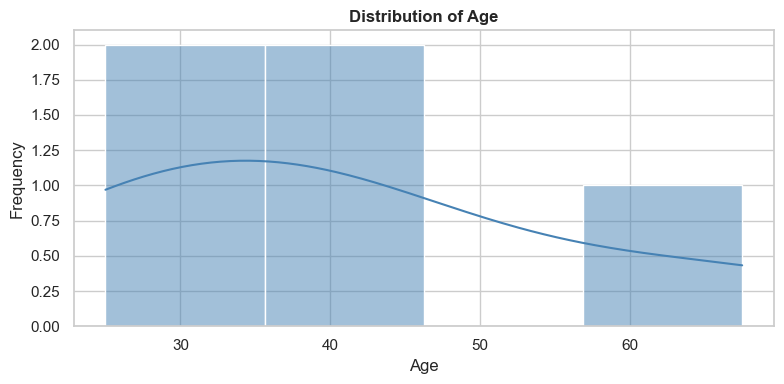

In [2]:
# Create a dummy dataset
data = {
    'Age': [25, 30, np.nan, 45, 120], 
    'Salary': [50000, 60000, 55000, np.nan, 70000],
    'City': ['NY', 'LA', 'NY', 'SF', 'LA'],
    'Purchased': ['No', 'Yes', 'Yes', 'No', 'Yes']
}
df = pd.DataFrame(data)

print("CLEANING")
cleaner = DataCleaner(df)
cleaner.handle_missing_values(strategy='median', columns=['Age', 'Salary'])
cleaner.auto_handle_outliers()
cleaned_df = cleaner.get_cleaned_dataFrame()
print(cleaned_df.head())

print("\nEDA")
analyzer = EDAAnalyzer(cleaned_df)
print(analyzer.get_summary_statistics())
figs = analyzer.plot_numerical_distributions()
figs[0]

In [3]:
print("\nFEATURE ENGINEERING")
engineer = FeatureEngineer(cleaned_df, target_column='Purchased')
engineer.apply_encoding()
engineer.apply_scaling()
X, y = engineer.get_processed_dataframe()
print(X.head())

INFO:src.feature_engineering.preprocessor:FeatureEngineer initialized
INFO:src.feature_engineering.preprocessor:Applied Label Encoding to target: Purchased
INFO:src.feature_engineering.preprocessor:Applied One-Hot Encoding to: ['City']
INFO:src.feature_engineering.preprocessor:Applied Standard Scaling to 2 numerical features.



FEATURE ENGINEERING
        Age    Salary  City_NY  City_SF
0 -1.075061 -1.281423     True    False
1 -0.739104  0.226134    False    False
2 -0.235170 -0.527645     True    False
3  0.268765 -0.150756    False     True
4  1.780570  1.733690    False    False


In [4]:
cleaned_df

,Age,Salary,City,Purchased
0,25.0,50000.0,NY,No
1,30.0,60000.0,LA,Yes
2,37.5,55000.0,NY,Yes
3,45.0,57500.0,SF,No
4,67.5,70000.0,LA,Yes


In [5]:
from sklearn.model_selection import train_test_split
from src.models.task_detector import TaskDetector
from src.models.trainer import ModelTrainer

print("--- TASK DETECTION ---")
detector = TaskDetector(cleaned_df, target_column='Purchased')
task = detector.detect_task()
print(f"Detected Task: {task}")

print("\n--- MODEL TRAINING ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

trainer = ModelTrainer(task_type=task)
training_results = trainer.train_models(X_train, y_train)

print("\n--- TRAINING SUMMARY ---")
for model_name, (trained_model, t_time) in training_results.items():
    print(f"{model_name}: {t_time} seconds")

INFO:src.models.task_detector:TaskDetector initialized for target: Purchased
INFO:src.models.task_detector:Task detected: Classification (Categorical/Boolean target).
INFO:src.models.trainer:Initialized ModelTrainer for task type: classification
INFO:src.models.trainer:Starting training loop for 8 models...
INFO:src.models.trainer:Training Logistic Regression...
INFO:src.models.trainer:successfully trained Logistic Regression in 0.0054s
INFO:src.models.trainer:Training Decision Tree...
INFO:src.models.trainer:successfully trained Decision Tree in 0.0033s
INFO:src.models.trainer:Training Random Forest...
INFO:src.models.trainer:successfully trained Random Forest in 0.1737s
INFO:src.models.trainer:Training AdaBoost...


--- TASK DETECTION ---
Detected Task: classification

--- MODEL TRAINING ---


INFO:src.models.trainer:successfully trained AdaBoost in 0.1254s
INFO:src.models.trainer:Training Gradient Boosting...
INFO:src.models.trainer:successfully trained Gradient Boosting in 0.1275s
INFO:src.models.trainer:Training XGBoost...
c:\Users\Mrunmayee Potdar\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:34:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
INFO:src.models.trainer:successfully trained XGBoost in 0.1789s
INFO:src.models.trainer:Training LightGBM...
INFO:src.models.trainer:successfully trained LightGBM in 2.8989s
INFO:src.models.trainer:Training CatBoost...
INFO:src.models.trainer:successfully trained CatBoost in 1.1584s



--- TRAINING SUMMARY ---
Logistic Regression: 0.0054 seconds
Decision Tree: 0.0033 seconds
Random Forest: 0.1737 seconds
AdaBoost: 0.1254 seconds
Gradient Boosting: 0.1275 seconds
XGBoost: 0.1789 seconds
LightGBM: 2.8989 seconds
CatBoost: 1.1584 seconds


In [6]:
from src.evaluation.evaluator import ModelEvaluator
from src.tuning.tuner import HyperparameterTuner

print("--- MODEL LEADERBOARD ---")
evaluator = ModelEvaluator(task_type=task)

leaderboard = evaluator.evaluate_models(training_results, X_test, y_test)
print(leaderboard)

print("\n--- HYPERPARAMETER TUNING ---")
best_model_name = leaderboard.iloc[0]['Model']
best_model_obj = training_results[best_model_name][0]

print(f"Attempting to tune the winning model: {best_model_name}")
tuner = HyperparameterTuner(task_type=task)
tuned_model = tuner.tune_model(best_model_name, best_model_obj, X_train, y_train)

print(f"\nTuning process finished. Returned model: {tuned_model}")

INFO:src.evaluation.evaluator:ModelEvaluator initialized for task: classification


--- MODEL LEADERBOARD ---
                 Model  F1_Score  Accuracy  Precision  Recall  \
0             AdaBoost       1.0       1.0        1.0     1.0   
1        Decision Tree       0.0       0.0        0.0     0.0   
2  Logistic Regression       0.0       0.0        0.0     0.0   
3    Gradient Boosting       0.0       0.0        0.0     0.0   
4        Random Forest       0.0       0.0        0.0     0.0   
5              XGBoost       0.0       0.0        0.0     0.0   
6             CatBoost       0.0       0.0        0.0     0.0   
7             LightGBM       0.0       0.0        0.0     0.0   

   Training_Time (s) ROC_AUC  
0             0.1254    None  
1             0.0033    None  
2             0.0054    None  
3             0.1275    None  
4             0.1737    None  
5             0.1789    None  
6             1.1584    None  
7             2.8989    None  

--- HYPERPARAMETER TUNING ---
Attempting to tune the winning model: AdaBoost

Tuning process finished. Retur

In [7]:
import sys
import os

project_root = os.path.abspath("..")   # Move from notebooks -> AutoML_studio

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

c:\Users\Mrunmayee Potdar\Desktop\AutoML_studio


c:\Users\Mrunmayee Potdar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.evaluation.comparator:ModelComparator initialized for task: classification
INFO:src.evaluation.comparator:Generating comprehensive model comparison report...
INFO:src.evaluation.comparator:Profiling hardware and stability metrics for Logistic Regression...
ERROR:src.evaluation.comparator:cross validation failed: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.
INFO:src.evaluation.comparator:Profiling hardware and stability metrics for Decision Tree...
ERROR:src.evaluation.comparator:cross validation failed: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.
INFO:src.evaluation.comparator:Profiling hardware and stabil

MODEL COMPARISON DASHBOARD


ERROR:src.evaluation.comparator:cross validation failed: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.
INFO:src.evaluation.comparator:Profiling hardware and stability metrics for XGBoost...
ERROR:src.evaluation.comparator:cross validation failed: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.
INFO:src.evaluation.comparator:Profiling hardware and stability metrics for LightGBM...
ERROR:src.evaluation.comparator:cross validation failed: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.
INFO:src.evaluation.comparator:Profiling hardware and stability metrics for CatBoost...
ERROR:src.evaluation.comparator:cross validation failed: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.
INFO:src.evaluation.comparator:Comparison report generated successfully.
INFO:src.explainability.shap_explainer:selecting shap explainer for model archit


Comprehensive Production Leaderboard:
                 Model  F1_Score  Inference_Latency (ms/sample)  \
0             CatBoost       0.0                         1.0858   
1  Logistic Regression       0.0                         1.1204   
2        Decision Tree       0.0                         1.3166   
3    Gradient Boosting       0.0                         2.1350   
4              XGBoost       0.0                         2.7844   
5             LightGBM       0.0                         3.0663   
6             AdaBoost       1.0                         9.0294   
7        Random Forest       0.0                        12.7874   

   Model_Size (KB)  CV_Mean_Score                Complexity  
0           163.96            0.0  High (Ensemble/Boosting)  
1             0.87            0.0   Low (Linear/Parametric)  
2             1.62            0.0   Medium (Non-Parametric)  
3            67.78            0.0  High (Ensemble/Boosting)  
4            71.57            0.0  High (Ensemb

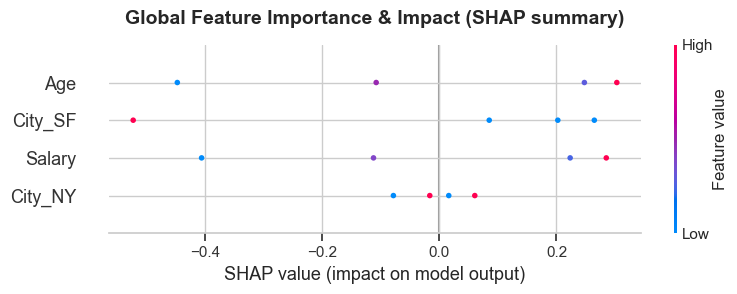

In [8]:
# testing Comparison Dashboard and Explainable AI
import logging
from src.evaluation.comparator import ModelComparator
from src.explainability.shap_explainer import SHAPExplainer

print("MODEL COMPARISON DASHBOARD")
comparator = ModelComparator(task_type=task)

full_report = comparator.generate_comparison_report(
    trained_models=training_results,
    leaderboard_df=leaderboard,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test
)

print("\nComprehensive Production Leaderboard:")
print(full_report[['Model', 'F1_Score', 'Inference_Latency (ms/sample)', 'Model_Size (KB)', 'CV_Mean_Score', 'Complexity']])

print("\nSHAP EXPLAINABLE AI")
champion_model_name = full_report.iloc[0]['Model']
champion_model_obj = training_results[champion_model_name][0]
print(f"Initializing SHAP Explainer for Champion Model: {champion_model_name}...")
explainer = SHAPExplainer(model=champion_model_obj, X_train=X_train, task_type=task)

print("\nTop Feature Importances by SHAP:")
print(explainer.get_feature_importance_dataframe())

print("\nRendering Global Summary Plot...")
global_fig = explainer.plot_global_summary(X_train)
global_fig

In [10]:
from src.mlflow_integration.tracker import MLflowTracker
from src.evaluation.recommender import ModelRecommender

print("AUTOMATED RECOMMENDATION ENGINE")
recommender = ModelRecommender(task_type=task)
rec_results = recommender.get_recommendation(comparision_df=full_report)

print(f"\nWINNER: {rec_results['winner_model']} (Composite Score: {rec_results['composite_score']})")
print("\n" + rec_results['justification_text'])

print("\nMLFLOW EXPERIMENT TRACKING")
tracker = MLflowTracker(experiment_name="AutoML_Studio_Local_Tests", 
                        tracking_uri="sqlite:///mlflow.db")

win_name = rec_results['winner_model']
win_model_obj = training_results[win_name][0]

win_metrics = full_report[full_report['Model'] == win_name].iloc[0].to_dict()

artifacts_to_log = {
    "shap_global_summary": global_fig
}

print(f"Logging Winner Model ('{win_name}') to MLflow...")
run_id = tracker.log_model_run(
    model_name=win_name,
    model_object=win_model_obj,
    metrics=win_metrics,
    params={"test_size": 0.2, "cv_folds": 5, "tuned": "False"},
    artifacts=artifacts_to_log,
    dataset_name="Dummy_Testing_Data"
)

print(f"\nSuccess! All metrics, SHAP plots, and model binaries logged to Run ID: {run_id}")

INFO:src.evaluation.recommender:ModelRecommender initialized for task: classification
INFO:src.evaluation.recommender:Recommendation generated: AdaBoost selected as winner


AUTOMATED RECOMMENDATION ENGINE

WINNER: AdaBoost (Composite Score: 0.7482)

**Executive summary & model recommendation**

AutoML Studio recommends deploying **AdaBoost** as the product winner. During testing, this model achieved an outstanding **F1_Score of 1.0000** paired with a robust **Cross-Validation Mean of 0.0000** ($\pm$0.0000), demonstrating exceptional generalization without severe overfitting.

**Why this model won:**
• **Hardware Efficiency:** It processes predictions with an inference latency of just **9.0294 ms/sample**, making it suitable for high-throughput, real-time API endpoints.
• **Architectural Profile:** Categorized as a *High (Ensemble/Boosting)* algorithm, it balances predictive firepower with manageable memory consumption (28.36 KB).
• **Competitive Comparison:** While **CatBoost** performed competitively (Rank #2 with a F1_Score of 0.0000), **AdaBoost** secured the winning position due to superior overall balance across stability, execution speed, and cross-

2026/07/26 15:38:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/26 15:38:07 INFO mlflow.store.db.utils: Updating database tables
INFO:src.mlflow_integration.tracker:Created new MLflow experiment: 'AutoML_Studio_Local_Tests' (id: 1)
INFO:src.mlflow_integration.tracker:Initiating MLflow run for model: AdaBoost...


Logging Winner Model ('AdaBoost') to MLflow...


INFO:src.mlflow_integration.tracker:Successfully logged 1 visual artifacts.
2026/07/26 15:38:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
INFO:src.mlflow_integration.tracker:MLflow run completed successfully! Run ID: 6851eec2e05e409e8222e521ac6f659c



Success! All metrics, SHAP plots, and model binaries logged to Run ID: 6851eec2e05e409e8222e521ac6f659c


In [4]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import pandas as pd
from src.prediction.predictor import ModelPredictor

X_raw, y_raw = make_classification(n_samples=100, n_features=4, random_state=42)
feature_names = ["Age", "Income", "Credit_Score", "Loan_Amount"]
X_train = pd.DataFrame(X_raw, columns=feature_names)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_raw)

predictor = ModelPredictor(
    model=model,
    task_type="classification",
    expected_features=feature_names,
    class_names=["Rejected", "Approved"]
)

single_request = {
    "Age": 0.5,
    "Income": -1.2,
    "Credit_Score": 0.8,
    "Loan_Amount": -0.3
}

print("--- TEST 1: SINGLE INSTANCE INFERENCE ---")
result_single = predictor.predict(single_request)
print(result_single)

batch_df = X_train.iloc[:2].copy()
batch_df = batch_df[["Loan_Amount", "Age", "Credit_Score", "Income"]] 

print("\n--- TEST 2: BATCH INFERENCE WITH SCRAMBLED COLUMNS ---")
result_batch = predictor.predict(batch_df)
for row in result_batch:
    print(row)

2026-07-28 18:27:40,012 - INFO - ModelPredictor initialized for CLASSIFICATION task with 4 expected features.
2026-07-28 18:27:40,027 - INFO - Starting inference validation and preprocessing...
2026-07-28 18:27:40,039 - INFO - Executing prediction for 1 instance(s)...
2026-07-28 18:27:40,090 - INFO - Inference completed successfully.
2026-07-28 18:27:40,102 - INFO - Starting inference validation and preprocessing...
2026-07-28 18:27:40,105 - INFO - Executing prediction for 2 instance(s)...
2026-07-28 18:27:40,133 - INFO - Inference completed successfully.


--- TEST 1: SINGLE INSTANCE INFERENCE ---
[{'row_index': 0, 'prediction': 'Rejected', 'raw_prediction_value': 0, 'task_type': 'Classification', 'confidence_score': '61.0%', 'confidence_value': 0.61, 'prob_Rejected': 0.61, 'prob_Approved': 0.39}]

--- TEST 2: BATCH INFERENCE WITH SCRAMBLED COLUMNS ---
{'row_index': 0, 'prediction': 'Approved', 'raw_prediction_value': 1, 'task_type': 'Classification', 'confidence_score': '100.0%', 'confidence_value': 1.0, 'prob_Rejected': 0.0, 'prob_Approved': 1.0}
{'row_index': 1, 'prediction': 'Rejected', 'raw_prediction_value': 0, 'task_type': 'Classification', 'confidence_score': '91.0%', 'confidence_value': 0.91, 'prob_Rejected': 0.91, 'prob_Approved': 0.09}


In [5]:
import os
import sys
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

sys.path.append(os.path.abspath(".."))

from src.persistence.manager import ModelPersistenceManager
from src.prediction.predictor import ModelPredictor

X_raw, y_raw = make_classification(n_samples=100, n_features=4, random_state=42)
feature_names = ["Age", "Income", "Credit_Score", "Loan_Amount"]
X_train = pd.DataFrame(X_raw, columns=feature_names)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_raw)

persister = ModelPersistenceManager(base_directory="saved_models_test")

dummy_metrics = {"F1_Score": 0.8950, "Accuracy": 0.9100, "Inference_Latency": "1.2 ms"}
version_id = persister.save_pipeline(
    model=model,
    model_name="Random Forest Classifier",
    task_type="classification",
    expected_features=feature_names,
    metrics=dummy_metrics,
    class_names=["Rejected", "Approved"]
)

print(f"\n---> Saved Model Version ID: {version_id}")

print("\n---> Listing All Saved Models in Directory:")
all_models = persister.list_saved_models()
for m in all_models:
    print(f"Version: {m['version_id']} | Model: {m['model_name']} | F1: {m['metrics'].get('F1_Score')}")

loaded_model, loaded_prep, loaded_meta = persister.load_pipeline(version_id)
print(f"\n---> Successfully reloaded metadata for: {loaded_meta['model_name']} (Trained on {loaded_meta['timestamp']})")

predictor = ModelPredictor(
    model=loaded_model,
    task_type=loaded_meta["task_type"],
    expected_features=loaded_meta["expected_features"],
    class_names=loaded_meta["class_names"],
    preprocessor=loaded_prep
)

sample_request = {"Age": 0.5, "Income": -1.2, "Credit_Score": 0.8, "Loan_Amount": -0.3}
prediction_result = predictor.predict(sample_request)

print("\n---> SANITY CHECK PREDICTION USING LOADED MODEL:")
print(prediction_result)

2026-07-28 19:09:53,737 - INFO - ModelPersistenceManager initialized. Artifacts directory: 'saved_models_test'
2026-07-28 19:09:53,816 - INFO - Pipeline artifact successfully saved to: saved_models_test\random_forest_classifier_v_20260728_190953.joblib
2026-07-28 19:09:53,826 - INFO - Metadata summary successfully saved to: saved_models_test\random_forest_classifier_v_20260728_190953_metadata.json
2026-07-28 19:09:53,831 - INFO - Loading pipeline artifact: saved_models_test\random_forest_classifier_v_20260728_190953.joblib ...
2026-07-28 19:09:53,879 - INFO - Loading companion metadata: saved_models_test\random_forest_classifier_v_20260728_190953_metadata.json ...
2026-07-28 19:09:53,882 - INFO - Successfully loaded version 'random_forest_classifier_v_20260728_190953' (Random Forest Classifier).
2026-07-28 19:09:53,884 - INFO - ModelPredictor initialized for CLASSIFICATION task with 4 expected features.
2026-07-28 19:09:53,885 - INFO - Starting inference validation and preprocessing...


---> Saved Model Version ID: random_forest_classifier_v_20260728_190953

---> Listing All Saved Models in Directory:
Version: random_forest_classifier_v_20260728_190953 | Model: Random Forest Classifier | F1: 0.895

---> Successfully reloaded metadata for: Random Forest Classifier (Trained on 20260728_190953)

---> SANITY CHECK PREDICTION USING LOADED MODEL:
[{'row_index': 0, 'prediction': 'Rejected', 'raw_prediction_value': 0, 'task_type': 'Classification', 'confidence_score': '61.0%', 'confidence_value': 0.61, 'prob_Rejected': 0.61, 'prob_Approved': 0.39}]


In [1]:
import os
import sys
import pandas as pd
from sklearn.datasets import make_classification

sys.path.append(os.path.abspath(".."))

from src.reports.generator import ReportGenerator

reporter = ReportGenerator(output_directory="test_reports")

dummy_dataset_summary = {
    "Total Rows": 1000,
    "Total Features": 12,
    "Target Column": "Churn_Status",
    "Missing Values Detected": "No",
    "Memory Footprint": "128.5 KB"
}

dummy_cleaning_summary = {
    "Outliers Handled (IQR)": "14 rows capped",
    "Categorical Encodings": "OneHotEncoding applied to 3 columns",
    "Feature Scaling": "MinMaxScaler applied to numeric features",
    "Duplicate Rows Removed": "2 rows dropped"
}

dummy_leaderboard = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Logistic Regression"],
    "F1_Score": [0.8942, 0.8810, 0.7923],
    "CV_Mean_Score": [0.8850, 0.8790, 0.7850],
    "Inference_Latency (ms/sample)": [1.201, 2.450, 0.105],
    "Complexity": ["Medium", "High", "Low"],
    "Composite_Score": [0.9120, 0.8950, 0.7410]
})

dummy_rec_text = (
    "AutoML Studio recommends deploying **Random Forest** as the product winner.<br/>"
    "During testing, this model achieved an outstanding F1_Score of 0.8942 paired with a robust "
    "Cross-Validation Mean of 0.8850, demonstrating exceptional generalization.<br/><br/>"
    "Why this model won: It balances predictive firepower with manageable memory consumption "
    "and processes predictions with an inference latency of just 1.201 ms/sample."
)

print("---> Generating test PDF report...")
pdf_path = reporter.generate_report(
    project_name="Customer Churn Prediction",
    task_type="classification",
    dataset_summary=dummy_dataset_summary,
    cleaning_summary=dummy_cleaning_summary,
    leaderboard_df=dummy_leaderboard,
    recommendation_text=dummy_rec_text
)

print(f"\n---> SUCCESS! Report generated at: {pdf_path}")

2026-07-29 23:00:09,691 - INFO - ReportGenerator initialized. Output folder: 'test_reports'
2026-07-29 23:00:09,708 - INFO - Compiling elements and rendering PDF...
2026-07-29 23:00:09,734 - INFO - PDF Report successfully generated at: test_reports\AutoML_Report_Customer_Churn_Prediction_20260729_230009.pdf


---> Generating test PDF report...

---> SUCCESS! Report generated at: c:\Users\Mrunmayee Potdar\Desktop\AutoML_studio\notebooks\test_reports\AutoML_Report_Customer_Churn_Prediction_20260729_230009.pdf


In [3]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.database.manager import DatabaseManager
db = DatabaseManager()

experiment_payload = {
    "project_name": "Customer Churn Optimization",
    "task_type": "classification",
    "dataset_name": "telecom_churn_data.csv",
    "best_model_name": "Random Forest",
    "primary_metric_name": "F1_Score",
    "primary_metric_value": 0.8942,
    "version_id": "random_forest_v_20260728_183310",
    "report_path": "/generated_reports/AutoML_Report_20260728.pdf"
}
print("---> Logging experiment to database...")
db.log_experiment(experiment_payload)
print("\n---> Fetching Experiment History:")
history = db.get_all_experiments()

import pandas as pd
print(pd.DataFrame(history)[["id", "project_name", "best_model", "metric"]])

2026-08-01 19:06:39,517-INFO-DatabaseManager initialized. Connected to DB: sqlite:///automl.db


---> Logging experiment to database...


TypeError: Session.__init__() got an unexpected keyword argument 'autoFlush'. Did you mean 'autoflush'?